<a href="https://colab.research.google.com/github/mmm10138/Machine-Learning/blob/main/HW_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Scientific Machine Learning - Fall 2025 - Homework 1**

# Part 1

## Q1
Using numpy but without using any ML library, implement a feedforward, fully connected neural network function with:
- one hidden layer consisting of 3 neurons, with activation function sigmoid (logistic function)
- one output layer consisting of 1 neuron, with no activation function (or: the activation function is the identity function)

In [2]:
import numpy as np

def neural_network(x, theta):
    """
    Neural network with 1 hidden layer.

    Parameters:
    - x: Input vector of shape (d0,).
    - theta: Parameters of the network, containing:
        * w1: Weights for the first layer of shape (d1, d0) (d1 neurons, d0 inputs).
        * b1: Bias for the first layer of shape (d1,).
        * w2: Weights for the second layer of shape (d2, d1) (d2 neurons, d1 inputs).
        * b2: Bias for the second layer of shape (d2,).

    Returns:
    - Output of the neural network of shape (d2,).
    """

    # Extract parameters
    w1, b1, w2, b2 = theta

    # First layer (hidden layer) with sigmoid activation
    z1 = w1@x+b1 #z1=w1x+b
    a1 = 1/(1+np.exp(-z1)) #a1=sigmoid(z1)

    # Second layer (output layer) with identity activation
    z2 = w2@a1+b2 #z2=w2x+b2
    output = z2  # Identity activation

    return output

## Q2
Test your neural network on the following input
$$
x = \begin{bmatrix} 0.5 \\ -0.2 \end{bmatrix}
$$
with the following parameters:
$$
w_1 = \begin{bmatrix} 1.0 & 0.0 \\ 0.5 & 0.5 \\ 0.0 & 1.0 \end{bmatrix}, \qquad
b_1 = \begin{bmatrix} 1.0 \\ 0.1 \\ -0.3 \end{bmatrix}
$$
$$
w_2 = \begin{bmatrix} -2.0 & 10.0 & 1.0 \end{bmatrix}, \qquad
b_2 = \begin{bmatrix} 0.2 \end{bmatrix}
$$
Hint: The value should be roughly 4.564.


In [7]:
# Example
x = np.array([0.5, -0.2])  # Input vector
# Weights for the first layer
w1 = np.array([[1.0,0.0],
              [0.5,0.5],
              [0.0,1.0]])
b1 = np.array([1.0,0.1,-0.3]) # Bias for the first layer
w2 = np.array([-2.0,10.0,1.0]) # Weights for the second layer
b2 = np.array([0.2]) # Bias for the second layer

theta = (w1, b1, w2, b2)

output = neural_network(x, theta)
output

array([4.56415673])

## Q3
Use the following function to produce a 3D plot of the function, with the same parameter $\theta=(w_1,b_1,w_2,b_2)$, on the square $[-10,10] \times [-10,10]$.

In [8]:
# Define the function for 3D plotting
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_neural_network_3d(theta):
    x_vals = np.linspace(-10, 10, 100)
    y_vals = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.zeros(X.shape)

    # Compute the network output for each (x, y) pair
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            z_val = neural_network(np.array([X[i, j], Y[i, j]]), theta)
            Z[i, j] = z_val.item()

    # Create the 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')

    ax.set_title("Neural Network Output (2D)")
    ax.set_xlabel("Input X")
    ax.set_ylabel("Input Y")
    ax.set_zlabel("Network Output")
    #ax.dist = 13
    ax.set_box_aspect(None, zoom=0.85)

    plt.show()


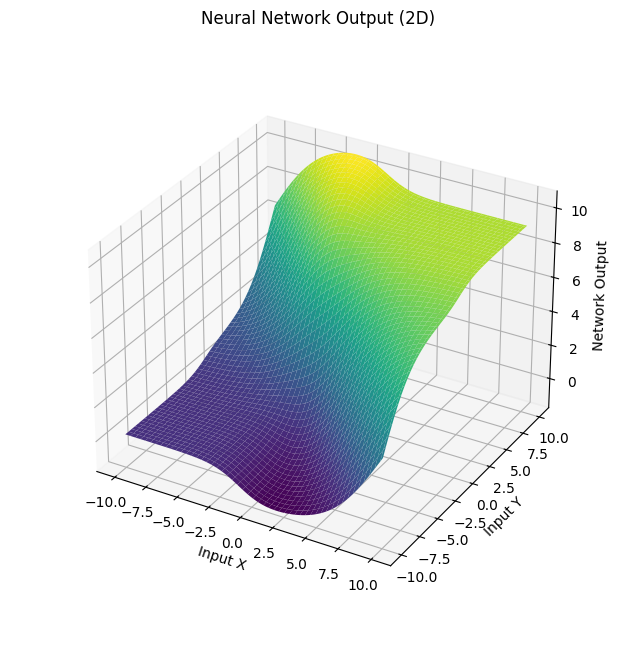

In [9]:
# Plot the neural network in 3D
# Use for instance:
plot_neural_network_3d(theta)

## Q4

Consider the following target function $x \mapsto \cos(\pi x_1/10)\cos(\pi x_2/10)$ plotted below:

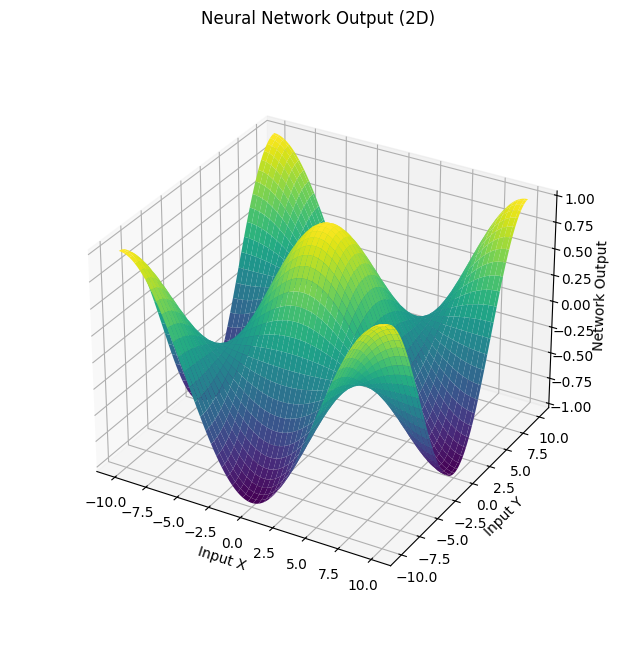

In [10]:
def target_func(x):
  return np.cos(np.pi*x[0]/10)*np.cos(np.pi*x[1]/10)

def plot_func_3d():
    x_vals = np.linspace(-10, 10, 100)
    y_vals = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.zeros(X.shape)

    # Compute the function value for each (x, y) pair
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            z_val = target_func([X[i, j], Y[i, j]])
            Z[i, j] = z_val

    # Create the 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')

    ax.set_title("Neural Network Output (2D)")
    ax.set_xlabel("Input X")
    ax.set_ylabel("Input Y")
    ax.set_zlabel("Network Output")
    #ax.dist = 13
    ax.set_box_aspect(None, zoom=0.85)

    plt.show()

# Plot the neural network in 3D
plot_func_3d()

Explain in words how you could tune the parameter $\theta$ so that the neural network function would be close to this target function.

The parameter θ could be tuned by function approximation methods that approximate the function. For instance using the infinity norm.

# Part 2

## Q1

Implement the same neural network as before, but now using the PyTorch library.

In [13]:
import torch
import torch.nn as nn

# Define the feedforward neural network
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        # Define the first layer (input to hidden layer)
        self.fc1 = nn.Linear(2,3)  # 2 inputs, 3 neurons in hidden layer
        self.activation = nn.Sigmoid()  # Sigmoid activation function

        # Define the second layer (hidden to output layer)
        self.fc2 = nn.Linear(3,1)  # 3 inputs, 1 output neuron

    def forward(self, x):
        # Pass through the first layer, then apply the activation
        out = self.activation(self.fc1(x))
        # Pass through the second layer (output layer without activation)
        out = self.fc2(out)
        return out


## Q2

Evaluate the neural network using the same parameters as in the previous part, and on the same input $x$.
Hint: The value should still be roughly 4.564.

In [15]:
# Initialize the network
model = FeedforwardNN()

# Manually set weights and biases to match the example
with torch.no_grad():
    model.fc1.weight = torch.nn.Parameter(torch.tensor([[1.0, 0.0], [0.5, 0.5], [0.0, 1.0]]))
    model.fc1.bias = torch.nn.Parameter(torch.tensor([1.0,0.1,-0.3]))
    model.fc2.weight = torch.nn.Parameter(torch.tensor([[-2.0,10.0,1.0]]))
    model.fc2.bias = torch.nn.Parameter(torch.tensor([0.2]))

# Define the input
x = torch.tensor([0.5, -0.2])

# Forward pass: calculate the output
output = model(x)

print("Network output:", output.item())

Network output: 4.564156532287598


## Q3

Use the following code to plot your function:

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_neural_network_pytorch_3d(model):
    # Generate a meshgrid over the input space [-10, 10] x [-10, 10]
    x_vals = np.linspace(-10, 10, 100)
    y_vals = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros(X.shape)

    # Evaluate the neural network over the grid
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            # Prepare the input in the form [x, y]
            input_tensor = torch.FloatTensor([X[i, j], Y[i, j]])
            Z[i, j] = model(input_tensor).item()  # Get the network output

    # Create a 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')

    # Add plot labels
    ax.set_title("Neural Network Output over Input Space [-10, 10] x [-10, 10]")
    ax.set_xlabel("Input X")
    ax.set_ylabel("Input Y")
    ax.set_zlabel("Network Output")
    #ax.dist = 13
    ax.set_box_aspect(None, zoom=0.85)

    plt.show()

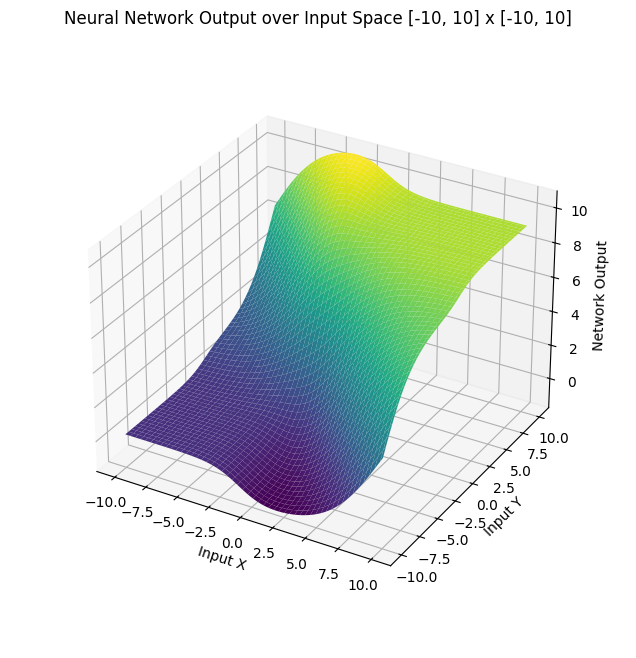

In [19]:
# Call the above function to plot your neural network, for isntance:
plot_neural_network_pytorch_3d(model)

## Q4
Using SGD, train the neural network to be close to the target function defined above. To this end, use the loss function defined as the mean-squared distance between the neural network function and the target function, when the input is sampled uniformly at random on $[-10,10] \times [-10,10]$.

Set the learning rate to 0.01. Train for $200$ epochs, using $10$ mini-batches of size $8$ in each epoch. Print the loss at each epoch.

At the end of training, plot your neural network function in 3D.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Define the target function (in PyTorch)
def target_function(x):
    return torch.cos(np.pi * x[:, 0] / 10) * torch.cos(np.pi * x[:, 1] / 10)

# Initialize the network, loss function, and optimizer
model = # TODO: create with FeedforwardNN class
loss_fn = # TODO: use nn.MSEloss
optimizer = # TODO: call optim.SGD

# Training parameters
epochs = # TODO  # Number of epochs
num_batches = # TODO  # Number of batches per epoch
batch_size = # TODO  # Batch size

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(num_batches):
        # Sample random input uniformly from [-10, 10] x [-10, 10]
        x_train = torch.FloatTensor(batch_size, 2).uniform_(-10, 10)
        y_train = target_function(x_train).unsqueeze(1)  # Compute target function values

        # Forward pass
        y_pred = # TODO: call model

        # Compute loss (mean squared error)
        loss = # TODO: call loss_fn

        # Backward pass and optimization step
        # TODO  # Zero out gradients
        # TODO  # Compute gradients
        # TODO  # Update parameters

        epoch_loss += loss.item()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/num_batches:.6f}')


Epoch [1/200], Loss: 0.554750
Epoch [2/200], Loss: 0.375579
Epoch [3/200], Loss: 0.389117
Epoch [4/200], Loss: 0.295097
Epoch [5/200], Loss: 0.275702
Epoch [6/200], Loss: 0.245708
Epoch [7/200], Loss: 0.230369
Epoch [8/200], Loss: 0.325703
Epoch [9/200], Loss: 0.336030
Epoch [10/200], Loss: 0.288970
Epoch [11/200], Loss: 0.207937
Epoch [12/200], Loss: 0.298012
Epoch [13/200], Loss: 0.259222
Epoch [14/200], Loss: 0.283693
Epoch [15/200], Loss: 0.262478
Epoch [16/200], Loss: 0.266166
Epoch [17/200], Loss: 0.266551
Epoch [18/200], Loss: 0.273813
Epoch [19/200], Loss: 0.277666
Epoch [20/200], Loss: 0.233644
Epoch [21/200], Loss: 0.266971
Epoch [22/200], Loss: 0.315220
Epoch [23/200], Loss: 0.179418
Epoch [24/200], Loss: 0.256374
Epoch [25/200], Loss: 0.201393
Epoch [26/200], Loss: 0.244006
Epoch [27/200], Loss: 0.246681
Epoch [28/200], Loss: 0.258103
Epoch [29/200], Loss: 0.305213
Epoch [30/200], Loss: 0.276796
Epoch [31/200], Loss: 0.262199
Epoch [32/200], Loss: 0.354046
Epoch [33/200], L

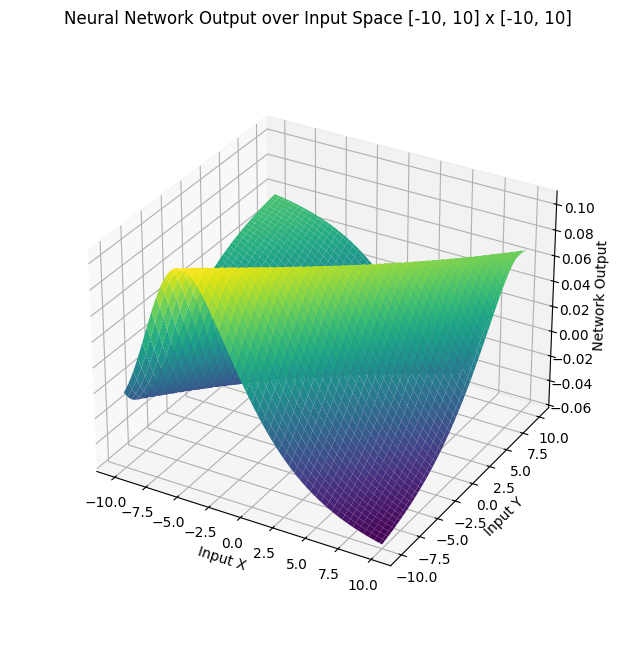

In [ ]:
plot_neural_network_pytorch_3d(model)

## Q5
Although neural networks with a single hidden layer satisfy a universal approximation theorem, they may require more than $3$ neurons in order to approximate well the target function. Let us try with more neurons.

Define a new neural network with the same architecture except for the fact that it has $200$ neurons (instead of $3$) in the hidden layer. Repeat the training and plot your result.

Epoch [1/200], Loss: 0.247433
Epoch [2/200], Loss: 0.227357
Epoch [3/200], Loss: 0.195637
Epoch [4/200], Loss: 0.289403
Epoch [5/200], Loss: 0.285311
Epoch [6/200], Loss: 0.309526
Epoch [7/200], Loss: 0.284229
Epoch [8/200], Loss: 0.308711
Epoch [9/200], Loss: 0.292694
Epoch [10/200], Loss: 0.297284
Epoch [11/200], Loss: 0.256593
Epoch [12/200], Loss: 0.232091
Epoch [13/200], Loss: 0.230699
Epoch [14/200], Loss: 0.249905
Epoch [15/200], Loss: 0.266986
Epoch [16/200], Loss: 0.218671
Epoch [17/200], Loss: 0.275118
Epoch [18/200], Loss: 0.274679
Epoch [19/200], Loss: 0.262034
Epoch [20/200], Loss: 0.178021
Epoch [21/200], Loss: 0.201182
Epoch [22/200], Loss: 0.188960
Epoch [23/200], Loss: 0.173418
Epoch [24/200], Loss: 0.339598
Epoch [25/200], Loss: 0.245043
Epoch [26/200], Loss: 0.234560
Epoch [27/200], Loss: 0.153777
Epoch [28/200], Loss: 0.272969
Epoch [29/200], Loss: 0.221030
Epoch [30/200], Loss: 0.194417
Epoch [31/200], Loss: 0.231854
Epoch [32/200], Loss: 0.234650
Epoch [33/200], L

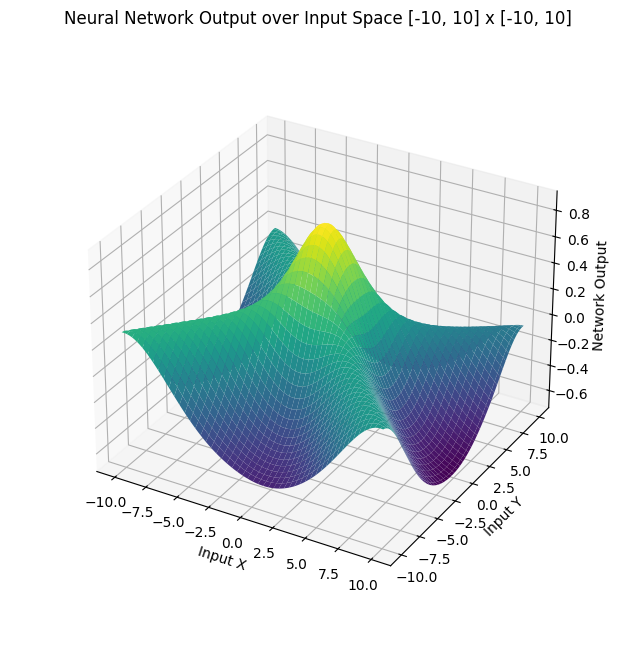

In [ ]:
import torch
import torch.nn as nn

# Define the feedforward neural network
class FeedforwardNNWide(nn.Module):
    def __init__(self):
        super(FeedforwardNNWide, self).__init__()
        # Define the first layer (input to hidden layer)
        self.fc1 = # TODO  # 2 inputs, 200 neurons in hidden layer
        self.activation = # TODO  # Sigmoid activation function

        # Define the second layer (hidden to output layer)
        self.fc2 = # TODO  # 200 inputs, 1 output neuron

    def forward(self, x):
        # Pass through the first layer, then apply the activation
        out = # TODO
        # Pass through the second layer (output layer without activation)
        out = # TODO
        return out

# Initialize the network, loss function, and optimizer
model_wide = # TODO
loss_fn = # TODO
optimizer = # TODO

# Training parameters
epochs = # TODO  # Number of epochs
num_batches = # TODO  # Number of batches per epoch
batch_size = # TODO  # Batch size

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(num_batches):
        # Sample random input uniformly from [-10, 10] x [-10, 10]
        x_train = torch.FloatTensor(batch_size, 2).uniform_(-10, 10)
        y_train = target_function(x_train).unsqueeze(1)  # Compute target function values

        # Forward pass
        y_pred = # TODO

        # Compute loss (mean squared error)
        loss = # TODO

        # Backward pass and optimization step
        # TODO  # Zero out gradients
        # TODO  # Compute gradients
        # TODO  # Update parameters

        epoch_loss += loss.item()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/num_batches:.6f}')

plot_neural_network_pytorch_3d(model_wide)

# Bonus Questions

- At the end of training, plot the loss vs epochs.
- Try to get a better fit of the target function (e.g., with more neurons, more layers, a different learning rate, or a different mini-batch size).

In [ ]:
# TODO: Hint: use larger mini-batch and smaller LR (together)

Epoch [1/200], Loss: 0.270219
Epoch [2/200], Loss: 0.239359
Epoch [3/200], Loss: 0.253688
Epoch [4/200], Loss: 0.251942
Epoch [5/200], Loss: 0.247963
Epoch [6/200], Loss: 0.259595
Epoch [7/200], Loss: 0.252649
Epoch [8/200], Loss: 0.252613
Epoch [9/200], Loss: 0.252299
Epoch [10/200], Loss: 0.243168
Epoch [11/200], Loss: 0.260856
Epoch [12/200], Loss: 0.253926
Epoch [13/200], Loss: 0.249593
Epoch [14/200], Loss: 0.244841
Epoch [15/200], Loss: 0.246525
Epoch [16/200], Loss: 0.241825
Epoch [17/200], Loss: 0.249518
Epoch [18/200], Loss: 0.248141
Epoch [19/200], Loss: 0.254176
Epoch [20/200], Loss: 0.265865
Epoch [21/200], Loss: 0.242943
Epoch [22/200], Loss: 0.243008
Epoch [23/200], Loss: 0.244982
Epoch [24/200], Loss: 0.232655
Epoch [25/200], Loss: 0.239972
Epoch [26/200], Loss: 0.252143
Epoch [27/200], Loss: 0.236540
Epoch [28/200], Loss: 0.233126
Epoch [29/200], Loss: 0.233414
Epoch [30/200], Loss: 0.228592
Epoch [31/200], Loss: 0.228431
Epoch [32/200], Loss: 0.241288
Epoch [33/200], L

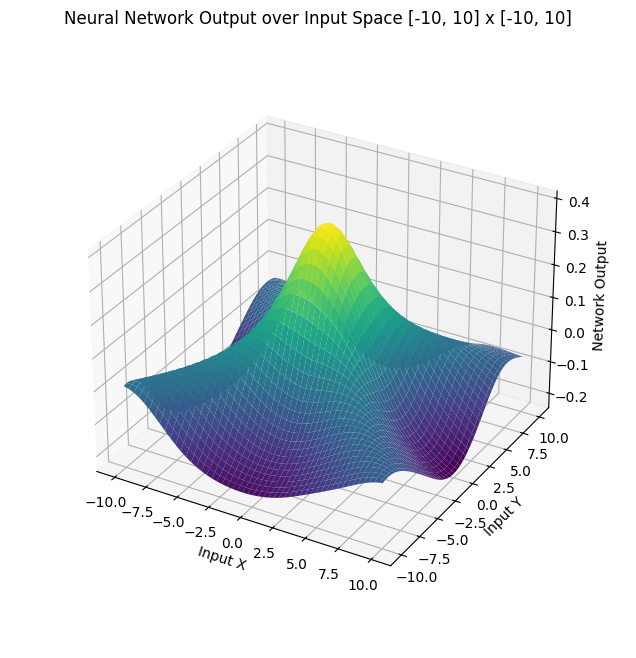

In [ ]:
import torch
import torch.nn as nn

# Define the feedforward neural network
class FeedforwardNNWide(nn.Module):
    def __init__(self):
        super(FeedforwardNNWide, self).__init__()
        # Define the first layer (input to hidden layer)
        self.fc1 = nn.Linear(2, 600)
        self.activation = nn.Sigmoid()  # Sigmoid activation function

        # Define the second layer (hidden to output layer)
        self.fc2 = nn.Linear(600, 1)

    def forward(self, x):
        # Pass through the first layer, then apply the activation
        out = self.activation(self.fc1(x))
        # Pass through the second layer (output layer without activation)
        out = self.fc2(out)
        return out

# Initialize the network, loss function, and optimizer
model_wide = FeedforwardNNWide()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_wide.parameters(), lr=0.001)

# Training parameters
epochs = 200  # Number of epochs
num_batches = 10  # Number of batches per epoch
batch_size = 100  # Batch size

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(num_batches):
        # Sample random input uniformly from [-10, 10] x [-10, 10]
        x_train = torch.FloatTensor(batch_size, 2).uniform_(-10, 10)
        y_train = target_function(x_train).unsqueeze(1)  # Compute target function values

        # Forward pass
        y_pred = model_wide(x_train)

        # Compute loss (mean squared error)
        loss = loss_fn(y_pred, y_train)

        # Backward pass and optimization step
        optimizer.zero_grad()  # Zero out gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update parameters

        epoch_loss += loss.item()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/num_batches:.6f}')

plot_neural_network_pytorch_3d(model_wide)

With a different learning rate and minibatch size, it explodes. Why?

Epoch [1/200], Loss: 37793.494355
Epoch [2/200], Loss: 232382780150168.312500
Epoch [3/200], Loss: 18500100315901485056.000000
Epoch [4/200], Loss: 5069950882308759710859264.000000
Epoch [5/200], Loss: 57612453088663335216305563238400.000000
Epoch [6/200], Loss: inf
Epoch [7/200], Loss: nan
Epoch [8/200], Loss: nan
Epoch [9/200], Loss: nan
Epoch [10/200], Loss: nan
Epoch [11/200], Loss: nan
Epoch [12/200], Loss: nan
Epoch [13/200], Loss: nan
Epoch [14/200], Loss: nan
Epoch [15/200], Loss: nan
Epoch [16/200], Loss: nan
Epoch [17/200], Loss: nan
Epoch [18/200], Loss: nan
Epoch [19/200], Loss: nan
Epoch [20/200], Loss: nan
Epoch [21/200], Loss: nan
Epoch [22/200], Loss: nan
Epoch [23/200], Loss: nan
Epoch [24/200], Loss: nan
Epoch [25/200], Loss: nan
Epoch [26/200], Loss: nan
Epoch [27/200], Loss: nan
Epoch [28/200], Loss: nan
Epoch [29/200], Loss: nan
Epoch [30/200], Loss: nan
Epoch [31/200], Loss: nan
Epoch [32/200], Loss: nan
Epoch [33/200], Loss: nan
Epoch [34/200], Loss: nan
Epoch [3

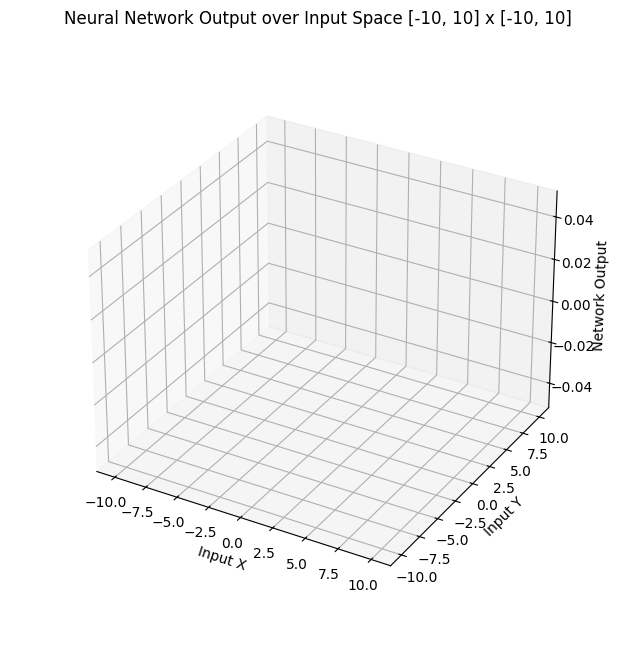

In [ ]:
import torch
import torch.nn as nn

# Define the feedforward neural network
class FeedforwardNNWide(nn.Module):
    def __init__(self):
        super(FeedforwardNNWide, self).__init__()
        # Define the first layer (input to hidden layer)
        self.fc1 = nn.Linear(2, 600)
        # torch.nn.init.normal_(self.fc1, mean=0.0, std=0.001)
        torch.nn.init.normal_(self.fc1.weight, mean=0.0, std=0.0001)
        self.activation = nn.Sigmoid()  # Sigmoid activation function

        # Define the second layer (hidden to output layer)
        self.fc2 = nn.Linear(600, 1)
        torch.nn.init.normal_(self.fc2.weight, mean=0.0, std=0.0001)

    def forward(self, x):
        # Pass through the first layer, then apply the activation
        out = self.activation(self.fc1(x))
        # Pass through the second layer (output layer without activation)
        out = self.fc2(out)
        return out

# Initialize the network, loss function, and optimizer
model_wide = FeedforwardNNWide()

# Initialization of parameters
# torch.nn.init.normal_(model.weight, mean=0.0, std=0.001)

loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_wide.parameters(), lr=0.01)

# Training parameters
epochs = 200  # Number of epochs
num_batches = 10  # Number of batches per epoch
batch_size = 8  # Batch size

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(num_batches):
        # Sample random input uniformly from [-10, 10] x [-10, 10]
        x_train = torch.FloatTensor(batch_size, 2).uniform_(-10, 10)
        y_train = target_function(x_train).unsqueeze(1)  # Compute target function values

        # Forward pass
        y_pred = model_wide(x_train)

        # Compute loss (mean squared error)
        loss = loss_fn(y_pred, y_train)

        # Backward pass and optimization step
        optimizer.zero_grad()  # Zero out gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update parameters

        epoch_loss += loss.item()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/num_batches:.6f}')

plot_neural_network_pytorch_3d(model_wide)